In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cftime
import xsdba
import xclim
import rioxarray
from xsdba.units import convert_units_to

print(xsdba.__version__)

0.5.0


In [2]:
# File paths
obs_path = "/home/dafcluster4/Documents/GitHub/TraCE_Sahul/02_data/02_processed/CHELSA/CHELSA_0p05_pr_climatology.nc"
sim_path = "/home/dafcluster4/Documents/GitHub/TraCE_Sahul/02_data/02_processed/TRACE/TraCE_0p05_pr_climatology.nc"
test_path = "/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/TraCE_downscaled_1500_1990_concat.nc"

# Open climatologies
obs = xr.open_dataset(obs_path, decode_times=False)["pr"]
sim = xr.open_dataset(sim_path, decode_times=False)["pr"]

# replace "time" with months Jan–Dec
months = xr.date_range(start="1985-01-01", end="1985-12-31", freq="ME", calendar="noleap", use_cftime=True)
obs = obs.assign_coords(time=months)
sim = sim.assign_coords(time=months)

# rename lon and lat
obs = obs.rename({"longitude": "lon", "latitude": "lat"})
sim = sim.rename({"longitude": "lon", "latitude": "lat"})

print(obs)
print(sim)

<xarray.DataArray 'pr' (time: 12, lat: 1276, lon: 1126)> Size: 69MB
[17241312 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 9kB 105.0 105.0 105.1 105.1 ... 161.2 161.2 161.2
  * lat      (lat) float64 10kB 11.25 11.2 11.15 11.1 ... -52.4 -52.45 -52.5
  * time     (time) object 96B 1985-01-31 00:00:00 ... 1985-12-31 00:00:00
Attributes:
    units:         kg/m2/s
    long_name:     precipitation
    grid_mapping:  crs
<xarray.DataArray 'pr' (time: 12, lat: 1276, lon: 1126)> Size: 69MB
[17241312 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 9kB 105.0 105.0 105.1 105.1 ... 161.2 161.2 161.2
  * lat      (lat) float64 10kB 11.25 11.2 11.15 11.1 ... -52.4 -52.45 -52.5
  * time     (time) object 96B 1985-01-31 00:00:00 ... 1985-12-31 00:00:00
Attributes:
    units:         kg/m2/s
    long_name:     precipitation
    grid_mapping:  crs


In [3]:
downTrace = xr.open_dataset(test_path, decode_times=False)["pr"]
# replace "time" with months Jan–Dec
months = xr.date_range(start="1500-01-01", end="1989-12-31", freq="ME", calendar="noleap", use_cftime=True)
downTrace = downTrace.assign_coords(time=months)
downTrace = downTrace.assign_attrs(units=sim.attrs["units"], long_name=sim.attrs["long_name"])
downTrace = downTrace.sel(time=slice("1910-01-01", "1989-12-31"))
# downTrace = downTrace.assign_coords(
#     lat=obs.lat,
#     lon=obs.lon)
print(downTrace)

<xarray.DataArray 'pr' (time: 960, lat: 1275, lon: 1125)> Size: 6GB
[1377000000 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 9kB 105.0 105.1 105.1 105.2 ... 161.1 161.2 161.2
  * lat      (lat) float64 10kB -52.47 -52.42 -52.37 ... 11.13 11.18 11.23
  * time     (time) object 8kB 1910-01-31 00:00:00 ... 1989-12-31 00:00:00
Attributes:
    standard_name:  precipitation_flux
    long_name:      precipitation
    units:          kg/m2/s
    grid_mapping:   crs


In [4]:
# Assign CRS if not already
obs = obs.rio.write_crs("EPSG:4326")
sim = sim.rio.write_crs("EPSG:4326")
downTrace = downTrace.rio.write_crs("EPSG:4326")

In [5]:
obs = obs.rename({"lat": "y", "lon": "x"})
sim = sim.rename({"lat": "y", "lon": "x"})
downTrace = downTrace.rename({"lat": "y", "lon": "x"})

# Match obs/sim to test grid
obs = obs.rio.reproject_match(downTrace)
sim = sim.rio.reproject_match(downTrace)

# rename spatial dimensions
obs = obs.rename({"y": "lat", "x": "lon"})
sim = sim.rename({"y": "lat", "x": "lon"})
downTrace = downTrace.rename({"y": "lat", "x": "lon"})

In [ ]:
# with xclim.core.units.units.context("hydro"):
#     obs = convert_units_to(obs, "mm d-1")
#     sim = convert_units_to(sim, "mm d-1")
#     downTrace = convert_units_to(downTrace, "mm d-1")

In [6]:
def print_bbox(da, name="DataArray"):
    print(f"{name} bounding box:")
    print(f"  lat: {float(da.lat.min())} → {float(da.lat.max())}")
    print(f"  lon: {float(da.lon.min())} → {float(da.lon.max())}")
    print()

print_bbox(obs, "obs")
print_bbox(sim, "sim")
print_bbox(downTrace, "test")


obs bounding box:
  lat: -52.474999999999994 → 11.225000000000009
  lon: 105.025 → 161.225

sim bounding box:
  lat: -52.474999999999994 → 11.225000000000009
  lon: 105.025 → 161.225

test bounding box:
  lat: -52.474999999999994 → 11.225000000000009
  lon: 105.025 → 161.225



/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


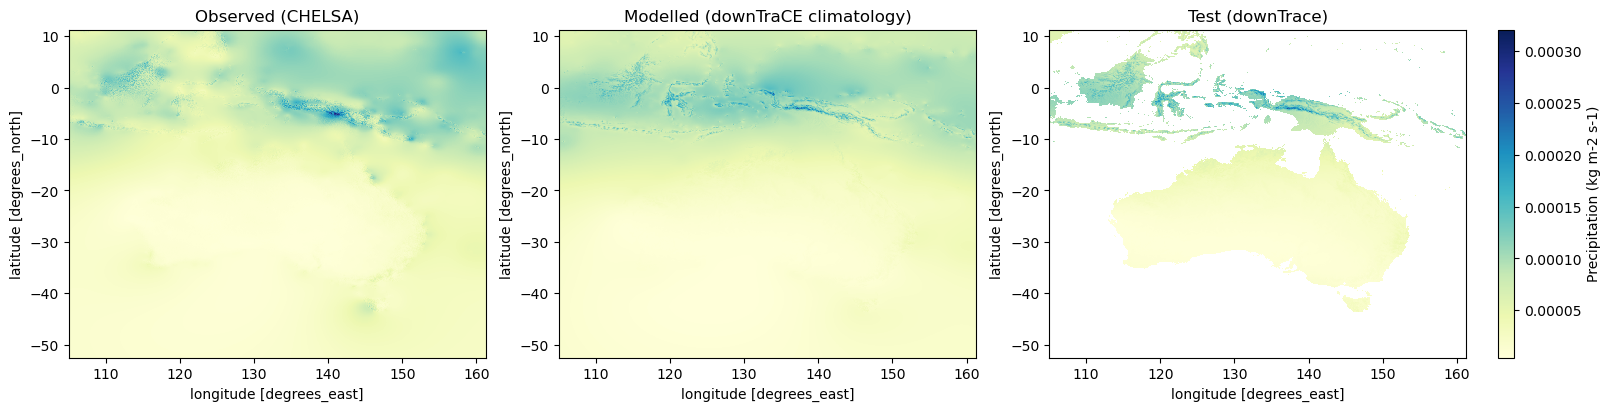

In [7]:
mean_obs = obs.groupby("time.month").mean("time", skipna=True).mean("month")
mean_sim = sim.groupby("time.month").mean("time", skipna=True).mean("month")
mean_test = downTrace.sel(time=slice("1980-01-01", "1989-12-31")).groupby("time.month").mean("time", skipna=True).mean("month")

# Compute shared min and max for consistent color scale
vmin = min(mean_obs.min().item(), mean_sim.min().item(), mean_test.min().item())
vmax = max(mean_obs.max().item(), mean_sim.max().item(), mean_test.max().item())
fig, axs = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
# Plot each raster
im0 = mean_obs.plot(ax=axs[0], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[0].set_title("Observed (CHELSA)")
im1 = mean_sim.plot(ax=axs[1], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[1].set_title("Modelled (downTraCE climatology)")
im2 = mean_test.plot(ax=axs[2], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[2].set_title("Test (downTrace)")
# Add a single shared colorbar on the right
cbar = fig.colorbar(im2, ax=axs, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label("Precipitation (kg m-2 s-1)")
plt.show()

In [8]:
# Train the QDM object
qdm = xsdba.adjustment.QuantileDeltaMapping.train(obs, sim, nquantiles=101, kind="*", group="time.month")
print(qdm.ds)

<xarray.Dataset> Size: 14GB
Dimensions:    (lat: 1275, lon: 1125, month: 12, quantiles: 101)
Coordinates:
  * lon        (lon) float64 9kB 105.0 105.1 105.1 105.2 ... 161.1 161.2 161.2
  * lat        (lat) float64 10kB -52.47 -52.42 -52.37 ... 11.13 11.18 11.23
  * quantiles  (quantiles) float32 404B 0.00495 0.01485 0.02475 ... 0.9851 0.995
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    crs        int64 8B 0
Data variables:
    af         (lat, lon, month, quantiles) float32 7GB 0.7314 0.7314 ... 1.038
    hist_q     (lat, lon, month, quantiles) float32 7GB 2.338e-05 ... 6.579e-05
Attributes:
    group:               time.month
    group_compute_dims:  ['time']
    group_window:        1
    _xsdba_adjustment:   {"py/object": "xsdba.adjustment.QuantileDeltaMapping...
    adj_params:          QuantileDeltaMapping(group=Grouper(name='time.month'...


In [9]:
# save to netcdf
qdm.ds.to_netcdf("/home/dafcluster4/Documents/GitHub/TraCE_Sahul/python_test/qdm_trained_pr_Sahul.nc")

In [ ]:
# Adjust test data with fitted QDM
adjTest = qdm.adjust(downTrace.sel(time=slice("1980-01-01", "1989-12-31")), extrapolation="constant", interp="cubic")

/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/xsdba/utils.py:399: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


In [15]:
adjTest.to_netcdf("/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/TraCE_22ka_downscaled_pr_1980_1990_qdm.nc")

In [14]:
adjTest = adjTest.transpose("time", "lat", "lon")
print(adjTest)

<xarray.DataArray 'scen' (time: 120, lat: 1275, lon: 1125)> Size: 688MB
array([[[          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        ...,
        [2.3244625e-06, 2.2185295e-06, 2.1236644e-06, ...,
                   nan,           nan,           nan],
        [2.2495303e-06, 2.1676215e-06, 2.1267056e-06, ...,
                   nan,           nan,           nan],
        [2.2441054e-06, 2.1796341e-06, 2.1090952e-06, ...,
                   nan,           nan,           nan]],

       [[          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
        [          nan,           nan,           nan, ...,
                   nan,           nan,           nan],
 

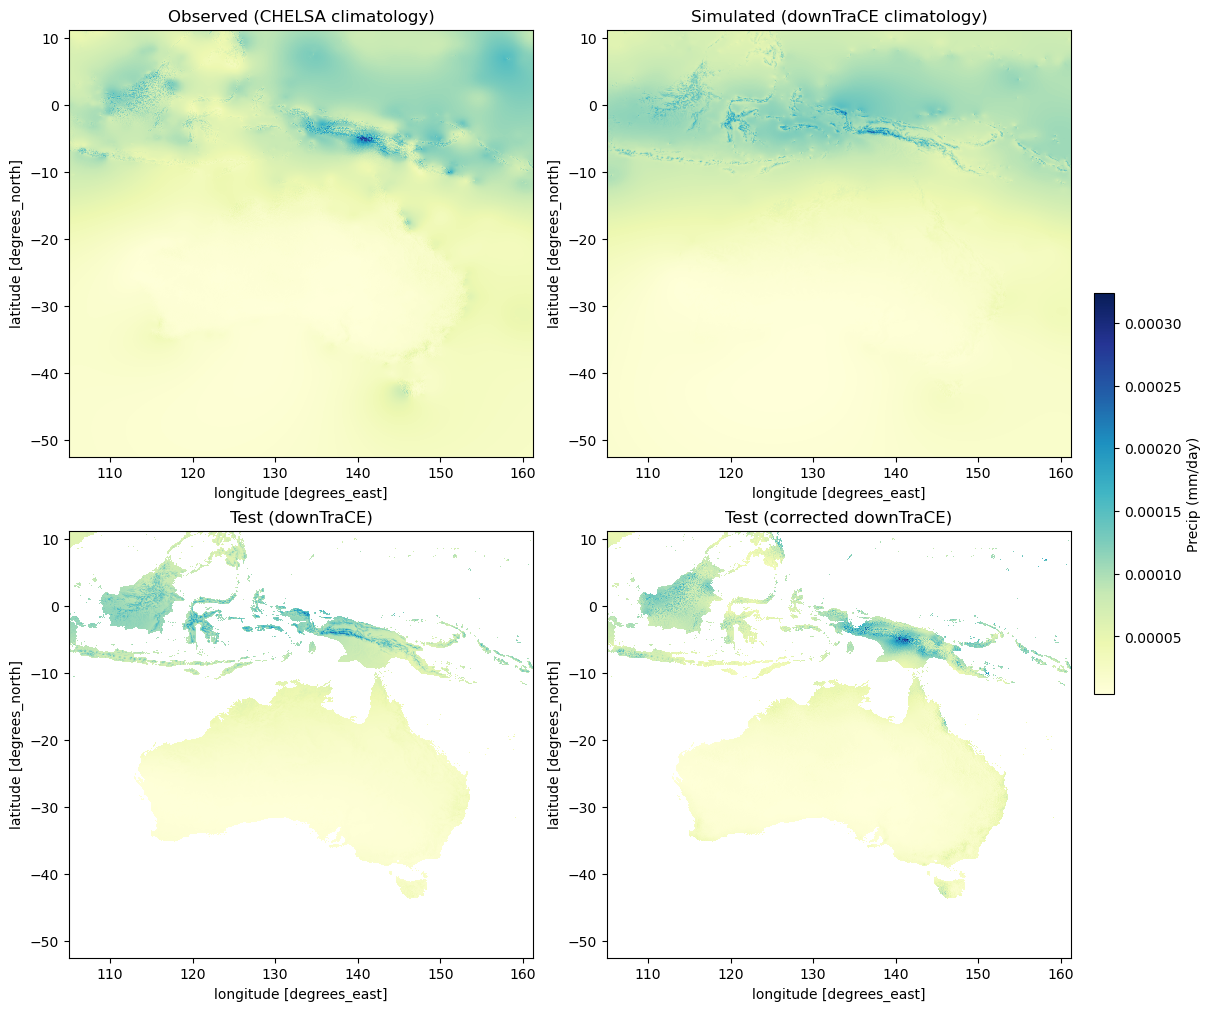

In [16]:
# Compute areal means
mean_obs = obs.groupby("time.month").mean("time", skipna=True).mean("month")
mean_sim = sim.groupby("time.month").mean("time", skipna=True).mean("month")
mean_test = downTrace.groupby("time.month").mean("time", skipna=True).mean("month")
mean_corrected = adjTest.groupby("time.month").mean("time", skipna=True).mean("month")

# Find common color scale
vmin = min(mean_obs.min().item(),
           mean_sim.min().item(),
           mean_test.min().item(),
           mean_corrected.min().item())

vmax = max(mean_obs.max().item(),
           mean_sim.max().item(),
           mean_test.max().item(),
           mean_corrected.max().item())

# Plot 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
im0 = mean_obs.plot(ax=axs[0,0], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[0,0].set_title("Observed (CHELSA climatology)")
mean_sim.plot(ax=axs[0,1], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[0,1].set_title("Simulated (downTraCE climatology)")
mean_test.plot(ax=axs[1,0], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[1,0].set_title("Test (downTraCE)")
mean_corrected.plot(ax=axs[1,1], cmap="YlGnBu", vmin=vmin, vmax=vmax, add_colorbar=False)
axs[1,1].set_title("Test (corrected downTraCE)")
# Shared colorbar
cbar = fig.colorbar(im0, ax=axs, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Precip (mm/day)")

plt.show()

<xarray.DataArray 'pr' (time: 12)> Size: 48B
array([5.6649194e-05, 5.6119457e-05, 4.9508759e-05, 4.6491139e-05,
       4.7058427e-05, 4.6682344e-05, 4.4136301e-05, 3.9321680e-05,
       3.7015139e-05, 3.9889946e-05, 4.4292763e-05, 5.1302184e-05],
      dtype=float32)
Coordinates:
  * time     (time) object 96B 1985-01-31 00:00:00 ... 1985-12-31 00:00:00
    crs      int64 8B 0
<xarray.DataArray 'pr' (time: 12)> Size: 48B
array([5.6825105e-05, 5.1718143e-05, 4.9100319e-05, 4.6910398e-05,
       4.6542053e-05, 4.4939537e-05, 4.1797917e-05, 3.8500981e-05,
       3.7556925e-05, 3.9398830e-05, 4.8196565e-05, 5.5865352e-05],
      dtype=float32)
Coordinates:
  * time     (time) object 96B 1985-01-31 00:00:00 ... 1985-12-31 00:00:00
    crs      int64 8B 0
<xarray.DataArray 'pr' (time: 120)> Size: 480B
array([6.1481674e-05, 5.5484241e-05, 4.1077707e-05, 3.3907549e-05,
       2.9785890e-05, 3.4721630e-05, 2.7709539e-05, 2.4621997e-05,
       2.0102174e-05, 2.4362236e-05, 3.1580312e-05, 4.53770

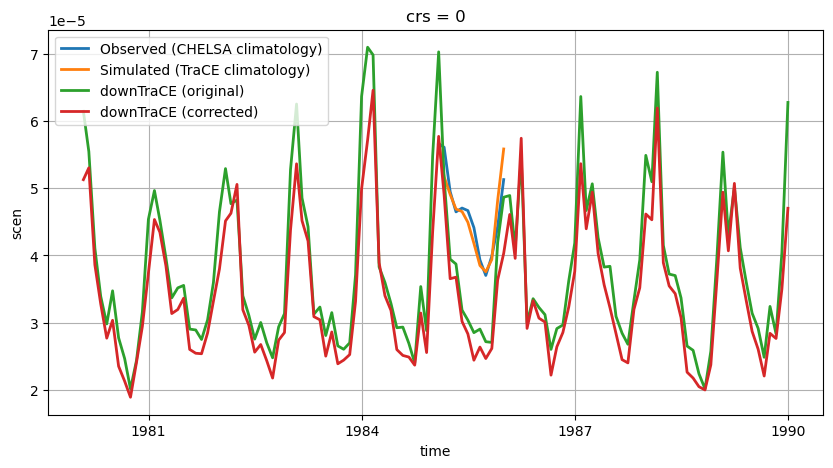

In [28]:
# Areal average time series
obs_area = obs.mean(["lat","lon"])
print(obs_area)
sim_area = sim.mean(["lat","lon"])
print(sim_area)
test_area = downTrace.sel(time=slice("1980-01-01", "1989-12-31")).mean(["lat","lon"])
print(test_area)
corrected_area = adjTest.mean(["lat","lon"])
print(corrected_area)

start = pd.Timestamp("1980-01-01")
end   = pd.Timestamp("1989-12-31")

fig2, ax2 = plt.subplots(figsize=(10,5))

obs_area.compute().plot(ax=ax2, label="Observed (CHELSA climatology)", lw=2)
sim_area.compute().plot(ax=ax2, label="Simulated (TraCE climatology)", lw=2)
test_area.compute().plot(ax=ax2, label="downTraCE (original)", lw=2)
corrected_area.compute().plot(ax=ax2, label="downTraCE (corrected)", lw=2)
# ax2.set_ylabel("Areal Average Precip (kg m2 s)")
# ax2.set_xlabel("Time")
# ax2.set_xlim(start, end)  # limit x-axis
ax2.legend()
ax2.grid(True)
plt.show()